<a href="https://colab.research.google.com/github/varunegit/carisurg-portfolio/blob/main/Week0_Tutorial3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Mount the Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

filepath = '/content/drive/MyDrive/Colab Notebooks/EmergencyTriageDataset_Reduced_Dirty.csv'
print("File 'EmergencyTriageDataset_Reduced_Dirty.csv' added")
df = pd.read_csv(filepath)

#Apply all data cleaning on the columns

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted
File 'EmergencyTriageDataset_Reduced_Dirty.csv' added
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


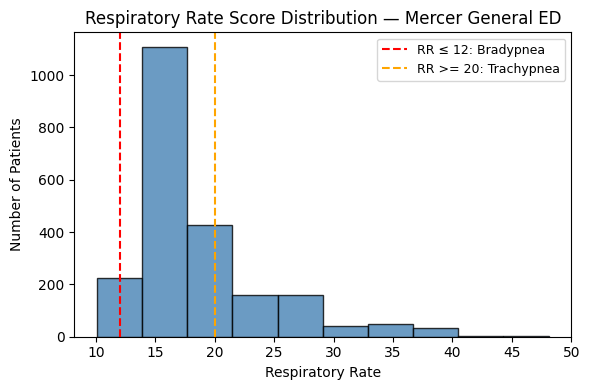

Saved: RR_histogram.png


In [87]:
#How are RR scores distributed across our patients-do most patients have slow breathing,
#or fast breathing or slow breating

#Histogram: RR distribution between patients

#RR ≤ 12: Bradypnea which is shown by red reference lines
#and RR >= 20: Trachypnea shown by orange reference lines
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['RR'], edgecolor='black',
        color='steelblue', alpha=0.8, align='left')

# Add a vertical line at the clinical threshold for severe impairment
ax.axvline(x=12, color='red', linestyle='--', linewidth=1.5,
           label='RR ≤ 12: Bradypnea')
ax.axvline(x=20, color='orange', linestyle='--', linewidth=1.5,
           label='RR >= 20: Trachypnea')

ax.set_title('Respiratory Rate Score Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Respiratory Rate')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('RR_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: RR_histogram.png")



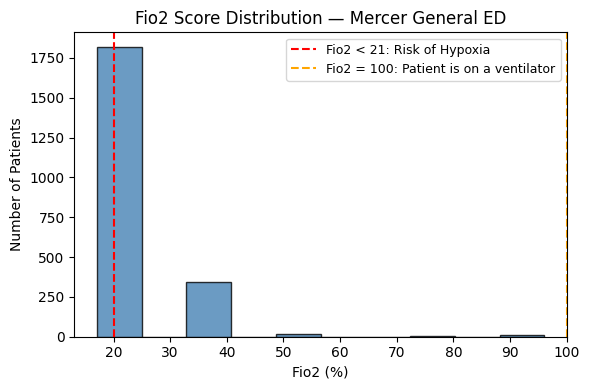

Saved: Fio2_histogram.png


In [88]:
#How are Fio2 scores distributed across our patients- What amount of patients
#are on a ventilator or have low scores of Fio2

#Histogram: Fio2 distribution between patients

#Fio2 = 100%: The patient is on a ventilator
#and Fio2 < 21%: The patient may develop Hypoxia where the body does not receive
#enough oxygen

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['Fio2'], edgecolor='black',
        color='steelblue', alpha=0.8, align='left')

# Add a vertical line at the clinical threshold for severe impairment
ax.axvline(x=20, color='red', linestyle='--', linewidth=1.5,
           label='Fio2 < 21: Risk of Hypoxia')
ax.axvline(x=100, color='orange', linestyle='--', linewidth=1.5,
           label='Fio2 = 100: Patient is on a ventilator')

ax.set_title('Fio2 Score Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Fio2 (%)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('Fio2_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: Fio2_histogram.png")

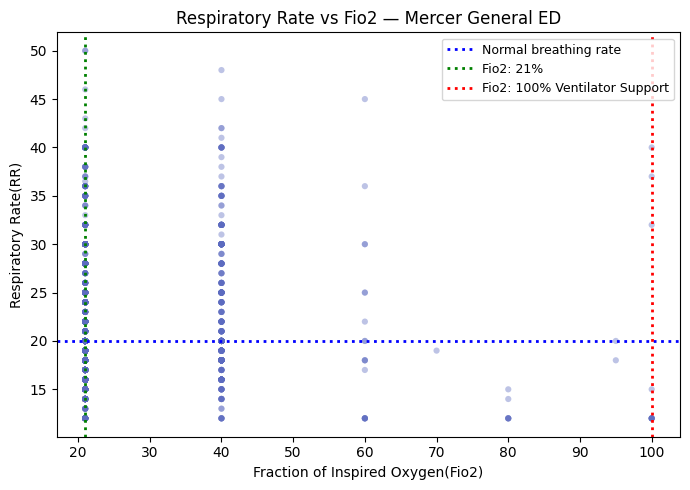

Saved: Fio2_vs_RR.png


In [89]:
#Is there a relationship between respiratory rate and Fio2 percentage in
#patients? Does it follow what physiology would predict?

#Scatter plot: Respiratory Rate vs Fio2 (%)

#Patients with a higher RR may require higher Fio2
#because they could be struggling to get enough oxygen

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['Fio2'], df['RR'],
                     alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

#Patients with a higher RR may require higher Fio2
ax.axhline(y=20, color='blue', linestyle=':', linewidth=2, label='Normal breathing rate')
ax.axvline(x=21, color='green', linestyle=':', linewidth=2, label='Fio2: 21%')
ax.axvline(x=100, color='red', linestyle=':', linewidth=2, label='Fio2: 100% Ventilator Support')

ax.set_title('Respiratory Rate vs Fio2 — Mercer General ED', fontsize=12)
ax.set_xlabel('Fraction of Inspired Oxygen(Fio2)')
ax.set_ylabel('Respiratory Rate(RR)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('Fio2_vs_RR.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: Fio2_vs_RR.png")


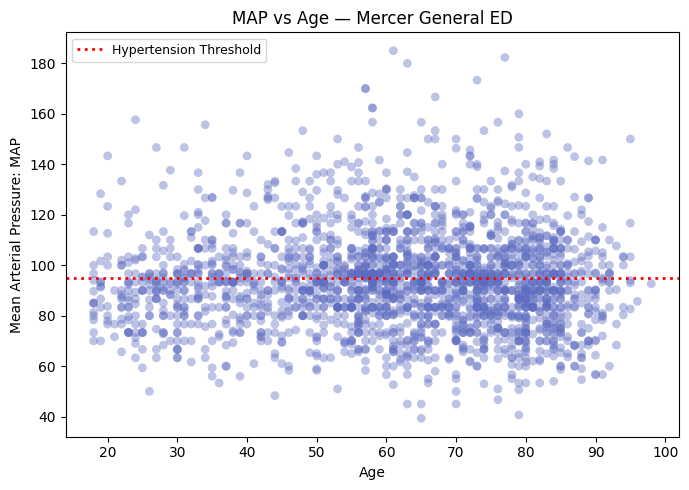

Saved: MAP_vs_Age.png


In [91]:
#Is there a relationship between MAP and age in
#patients? Does it follow what physiology would predict?

#Scatter plot: age vs MAP

#Patients would usually have a higher MAP as age increase
#different factors also can affect MAP other than age
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['Age'], df['MAP'],
                     alpha=0.4, s=40, color='#5C6BC0', edgecolors='none')

#Patients with a higher RR may require higher Fio2
ax.axhline(y=95, color='red', linestyle=':', linewidth=2, label='Hypertension Threshold')

ax.set_title('MAP vs Age — Mercer General ED', fontsize=12)
ax.set_xlabel('Age')
ax.set_ylabel('Mean Arterial Pressure: MAP')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('MAP_vs_Age.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: MAP_vs_Age.png")